# 02 — Reaction bake-off: дают ли уровни edge? (4 метода, пул)

Единый причинный движок: каждый метод → активные уровни во времени → касания →
signed forward-доходность vs baseline (безусловный дрейф). Плюс плотность уровней.

**Сторона по подходу:** прошлый close ниже уровня + бар достал снизу = тест
**сопротивления** (шорт); прошлый close выше + бар достал сверху = **поддержка** (лонг).
signed return > 0 ⇔ отскок сработал. Пул по ~50 символам, 2024, 1h. 2025-26 — на потом.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import pandas as pd

full = [s for s in sorted(p.name for p in loader.DATA_ROOT.iterdir() if p.is_dir())
        if len(list((loader.DATA_ROOT / s).glob("*.parquet"))) >= 28]
UNIV = full[::3][:50]               # ~50 spread across the alphabet
START, END, TF = "2024-01-01", "2025-01-01", "1h"
TOL = 0.0015                        # touch tolerance (0.15%)
CD = 6                              # global cooldown between events (bars)
LIFE = 720                          # a pivot level stays active 720 bars (~30d)
H = [4, 12, 24]; HMAX = 24          # forward horizons (hours)
TOL_DENS = 0.003                    # 'near a level' band for the density metric
print(len(UNIV), "symbols:", UNIV[:8], "...")

47 symbols: ['API3USDT', 'ARUSDT', 'AUCTIONUSDT', 'AXSUSDT', 'BCHUSDT', 'BICOUSDT', 'BSVUSDT', 'CAKEUSDT'] ...


In [2]:
def pivots(df, k):
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); n = len(df)
    hi = np.zeros(n, bool); lo = np.zeros(n, bool)
    for i in range(k, n - k):
        wH = h[i - k:i + k + 1]; wL = l[i - k:i + k + 1]
        if h[i] == wH.max() and (wH == h[i]).sum() == 1: hi[i] = True
        if l[i] == wL.min() and (wL == l[i]).sum() == 1: lo[i] = True
    return hi, lo

def pivot_segments(df, k, life=LIFE):
    """Each confirmed pivot price active from bar (i+k) for `life` bars. Causal."""
    hi, lo = pivots(df, k); n = len(df)
    h = df["high"].to_numpy(); l = df["low"].to_numpy()
    segs = []
    for i in np.where(hi)[0]:
        c = i + k; segs.append((h[i], c, min(c + life, n)))
    for i in np.where(lo)[0]:
        c = i + k; segs.append((l[i], c, min(c + life, n)))
    return segs

def cluster_segments(df, k=10, R=24, life=LIFE, tol=0.006, mint=3):
    """Recluster trailing confirmed pivots every R bars (causal). Each zone level
    is active until the next recompute."""
    hi, lo = pivots(df, k); n = len(df)
    h = df["high"].to_numpy(); l = df["low"].to_numpy()
    conf = []  # (conf_idx, price)
    for i in np.where(hi)[0]: conf.append((i + k, h[i]))
    for i in np.where(lo)[0]: conf.append((i + k, l[i]))
    conf = np.array(sorted(conf)) if conf else np.empty((0, 2))
    segs = []
    for r in range(k, n, R):
        if len(conf) == 0: break
        m = (conf[:, 0] <= r) & (conf[:, 0] > r - life)
        px = np.sort(conf[m, 1])
        if len(px) < mint: continue
        cl = [[px[0]]]
        for x in px[1:]:
            if (x - cl[-1][0]) / cl[-1][0] <= tol: cl[-1].append(x)
            else: cl.append([x])
        for c in cl:
            if len(c) >= mint:
                segs.append((float(np.mean(c)), r, min(r + R, n)))
    return segs

def donchian_levels(df, N=48):
    res = df["high"].rolling(N).max().shift(1).to_numpy()
    sup = df["low"].rolling(N).min().shift(1).to_numpy()
    return res, sup

In [3]:
def touches_static(df, segs, tol=TOL):
    """Scan segments for approach-touches. Returns sorted list of (t, side).
    side='res' (approach from below, short) / 'sup' (from above, long)."""
    c = df["close"].to_numpy(); h = df["high"].to_numpy(); l = df["low"].to_numpy(); n = len(df)
    ev = []
    for L, a, b in segs:
        a = max(a, 1)
        for t in range(a, b):
            if c[t - 1] < L * (1 - tol) and h[t] >= L * (1 - tol):
                ev.append((t, "res"))
            elif c[t - 1] > L * (1 + tol) and l[t] <= L * (1 + tol):
                ev.append((t, "sup"))
    return ev

def touches_donchian(df, N=48, tol=TOL):
    res, sup = donchian_levels(df, N)
    c = df["close"].to_numpy(); h = df["high"].to_numpy(); l = df["low"].to_numpy(); n = len(df)
    ev = []
    for t in range(N + 1, n):
        if c[t - 1] < res[t] * (1 - tol) and h[t] >= res[t] * (1 - tol): ev.append((t, "res"))
        elif c[t - 1] > sup[t] * (1 + tol) and l[t] <= sup[t] * (1 + tol): ev.append((t, "sup"))
    return ev

def dedup(ev, cd=CD):
    """Global cooldown: keep events sorted by t, drop any within cd bars of the last kept."""
    ev = sorted(set(ev))
    out = []; last = -10**9
    for t, s in ev:
        if t - last >= cd: out.append((t, s)); last = t
    return out

def fwd_signed(close, t, side, h):
    r = close[t + h] / close[t] - 1.0
    return r if side == "sup" else -r   # long support / short resistance

def density(df, segs, tol=TOL_DENS):
    c = df["close"].to_numpy(); n = len(df); near = np.zeros(n, bool)
    for L, a, b in segs:
        near[a:b] |= np.abs(c[a:b] - L) / L <= tol
    return near.mean()

def density_donchian(df, N=48, tol=TOL_DENS):
    res, sup = donchian_levels(df, N); c = df["close"].to_numpy()
    near = (np.abs(c - res) / res <= tol) | (np.abs(c - sup) / sup <= tol)
    return np.nanmean(near)

In [4]:
METHODS = {
    "fractals_k2": dict(kind="static", build=lambda df: pivot_segments(df, k=2)),
    "swings_k10":  dict(kind="static", build=lambda df: pivot_segments(df, k=10)),
    "clusters":    dict(kind="static", build=lambda df: cluster_segments(df, k=10)),
    "donchian_48": dict(kind="donchian"),
}

rows = []                      # one row per touch event
dens = {m: [] for m in METHODS}
drift_sum = {h: 0.0 for h in H}; drift_cnt = {h: 0 for h in H}

for si, sym in enumerate(UNIV):
    df = ohlcv(sym, START, END, TF)
    if len(df) < HMAX + 50: continue
    c = df["close"].to_numpy(); n = len(df)
    # baseline drift: unconditional forward return at every bar
    for h in H:
        r = c[h:] / c[:-h] - 1.0
        drift_sum[h] += float(np.nansum(r)); drift_cnt[h] += int(np.isfinite(r).sum())
    for m, cfg in METHODS.items():
        if cfg["kind"] == "static":
            segs = cfg["build"](df)
            ev = dedup(touches_static(df, segs)); dens[m].append(density(df, segs))
        else:
            ev = dedup(touches_donchian(df)); dens[m].append(density_donchian(df))
        for t, side in ev:
            if t + HMAX >= n: continue
            row = dict(method=m, sym=sym, side=side)
            for h in H: row[f"r{h}"] = fwd_signed(c, t, side, h)
            rows.append(row)
    if (si + 1) % 10 == 0: print(f"  {si+1}/{len(UNIV)} symbols done")

ev = pd.DataFrame(rows)
drift = {h: drift_sum[h] / drift_cnt[h] for h in H}
print("\ntotal events:", len(ev))
print("baseline drift (unconditional fwd ret):", {h: round(drift[h]*100, 3) for h in H}, "%")

  10/47 symbols done


  20/47 symbols done


  30/47 symbols done


  40/47 symbols done



total events: 162032
baseline drift (unconditional fwd ret): {4: 0.03, 12: 0.09, 24: 0.176} %


## Сводка: edge каждого метода против baseline

`edge` = средняя signed-доходность касаний минус baseline той же стороны (поддержка: +дрейф,
сопротивление: −дрейф). `mean/std` — риск-adjusted. Издержки ~0.15% round-trip держим в уме.

In [5]:
def summarize(g):
    out = {"n": len(g)}
    for h in H:
        x = g[f"r{h}"].to_numpy()
        base = drift[h]  # signed baseline differs by side; handle per-side below
        out[f"mean{h}"] = x.mean() * 100
        out[f"ms{h}"] = x.mean() / x.std() if x.std() > 0 else np.nan
    return pd.Series(out)

tbl = ev.groupby("method").apply(summarize, include_groups=False)
# baseline-adjusted edge per side then recombine by event mix
def edge_table(df_ev):
    recs = []
    for m, g in df_ev.groupby("method"):
        rec = {"method": m, "n": len(g)}
        for h in H:
            e = 0.0
            for side, gg in g.groupby("side"):
                b = drift[h] if side == "sup" else -drift[h]
                e += (gg[f"r{h}"].mean() - b) * len(gg)
            rec[f"edge{h}%"] = e / len(g) * 100
        recs.append(rec)
    return pd.DataFrame(recs).set_index("method")

edge = edge_table(ev)
edge["density%"] = [np.mean(dens[m]) * 100 for m in edge.index]
edge["raw_mean12%"] = [ev[ev.method == m]["r12"].mean() * 100 for m in edge.index]
edge["ms12"] = [ev[ev.method == m]["r12"].mean() / ev[ev.method == m]["r12"].std() for m in edge.index]
edge.round(3)

,n,edge4%,edge12%,edge24%,density%,raw_mean12%,ms12
method,,,,,,,
clusters,17731,0.016,0.011,0.004,8.198,0.012,0.003
donchian_48,21983,-0.010,-0.049,-0.219,4.973,-0.049,-0.011
fractals_k2,66536,-0.007,0.028,0.022,81.220,-0.019,-0.005
swings_k10,55782,0.010,0.020,0.008,44.106,0.005,0.001


[saved] notebooks\levels\_out\02_edge_bakeoff.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/02_edge_bakeoff.png')

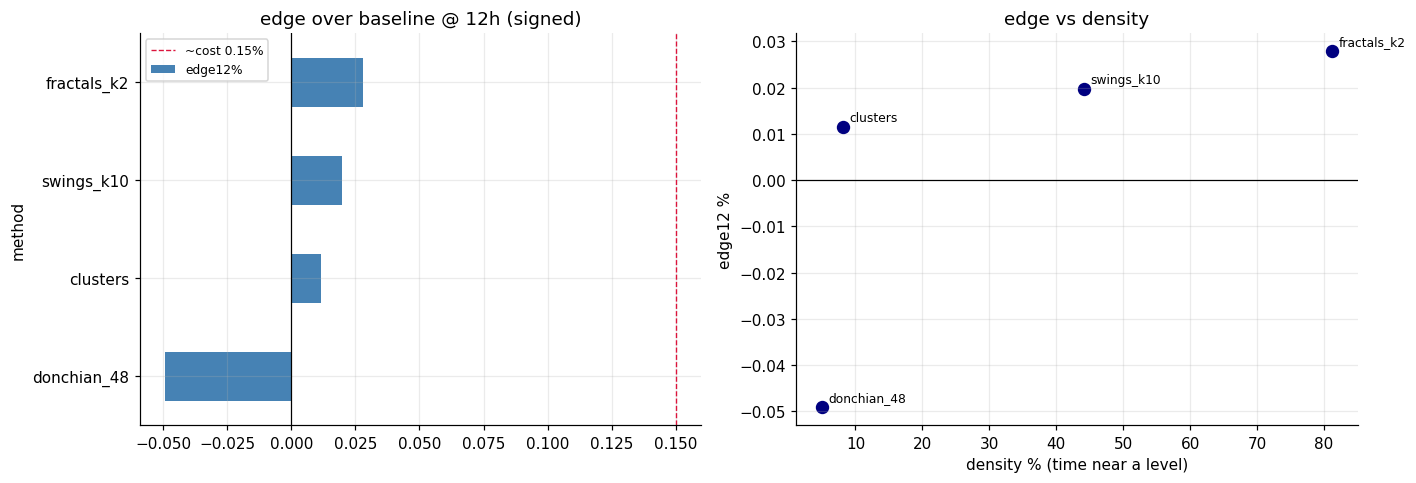

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
edge["edge12%"].sort_values().plot.barh(ax=a1, color="steelblue")
a1.axvline(0, color="k", lw=0.8); a1.axvline(0.15, color="crimson", ls="--", lw=0.9, label="~cost 0.15%")
a1.set_title("edge over baseline @ 12h (signed)"); a1.legend(fontsize=8)
a2.scatter(edge["density%"], edge["edge12%"], s=60, color="navy")
for m, r in edge.iterrows(): a2.annotate(m, (r["density%"], r["edge12%"]), fontsize=8, xytext=(4,4), textcoords="offset points")
a2.axhline(0, color="k", lw=0.8); a2.set_xlabel("density % (time near a level)"); a2.set_ylabel("edge12 %")
a2.set_title("edge vs density")
show("02_edge_bakeoff")

## Итог

Читаем таблицу: какой метод даёт положительный edge сверх baseline и издержек, при
разумной плотности и достаточном n. Это решает, на каком(их) методе(ах) строить стратегию
разворота. Дальше (nb03): добавить volume-profile, проверить лучший метод OOS (2025-26),
посмотреть распределение/хвосты и forward-путь, а не только среднее.